In [1]:
import os
from typing import Optional, Union, Tuple

import torch
from torch import Tensor
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import Node2Vec


@torch.no_grad()
def _infer_device(device: Optional[Union[str, torch.device]] = None) -> torch.device:
    if device is not None:
        return torch.device(device)
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def node2vec_gpu_embedding(
    edge_index: Tensor,
    num_nodes: int,
    embedding_dim: int = 128,
    walk_length: int = 20,
    context_size: int = 10,
    walks_per_node: int = 10,
    num_negative_samples: int = 1,
    p: float = 1.0,
    q: float = 1.0,
    sparse: bool = True,
    lr: float = 0.01,
    epochs: int = 50,
    batch_size: int = 256,
    num_workers: int = 0,
    device: Optional[Union[str, torch.device]] = None,
    seed: int = 42,
    log_every: int = 10,
) -> Tuple[Tensor, Node2Vec]:
    """
    Trains a PyG Node2Vec model and returns node embeddings.

    Notes on GPU:
      - The embedding model and loss run on GPU if `device='cuda'`.
      - Random walk sampling in PyG Node2Vec is typically performed on CPU via a DataLoader.
        This is normal: you'll still get GPU acceleration for the training step.

    Args:
        edge_index: LongTensor [2, E] with COO edges.
        num_nodes: Number of nodes in the graph.
        embedding_dim: Output embedding size.
        walk_length/context_size/walks_per_node: Node2Vec walk params.
        num_negative_samples: Negative samples per positive.
        p, q: Node2Vec return/in-out params.
        sparse: Use sparse gradients for embeddings (recommended for large graphs).
        lr: Learning rate.
        epochs: Training epochs.
        batch_size: Batch size for sampled walks.
        num_workers: DataLoader workers for sampling.
        device: 'cuda', 'cpu', or torch.device. If None, auto-detect.
        seed: Random seed.
        log_every: Print loss every `log_every` epochs.

    Returns:
        embeddings: FloatTensor [num_nodes, embedding_dim] on CPU.
        model: Trained torch_geometric.nn.Node2Vec model (on `device`).
    """
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    dev = _infer_device(device)

    if edge_index.dtype != torch.long:
        edge_index = edge_index.long()
    edge_index = edge_index.contiguous()

    # Build PyG Node2Vec model:
    model = Node2Vec(
        edge_index=edge_index,
        embedding_dim=embedding_dim,
        walk_length=walk_length,
        context_size=context_size,
        walks_per_node=walks_per_node,
        num_negative_samples=num_negative_samples,
        p=p,
        q=q,
        num_nodes=num_nodes,
        sparse=sparse,
    ).to(dev)

    # Random walk loader (sampling usually on CPU, yielding walk tensors)
    loader = model.loader(
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
    )

    # Optimizer: SparseAdam is a good default for sparse embeddings
    if sparse:
        optimizer = torch.optim.SparseAdam(list(model.parameters()), lr=lr)
    else:
        optimizer = torch.optim.Adam(list(model.parameters()), lr=lr)

    model.train()
    for epoch in range(1, epochs + 1):
        total_loss = 0.0
        total_batches = 0

        for pos_rw, neg_rw in loader:
            optimizer.zero_grad()

            # Move random walks onto GPU for the loss computation
            pos_rw = pos_rw.to(dev, non_blocking=True)
            neg_rw = neg_rw.to(dev, non_blocking=True)

            loss = model.loss(pos_rw, neg_rw)
            loss.backward()
            optimizer.step()

            total_loss += float(loss)
            total_batches += 1

        avg_loss = total_loss / max(total_batches, 1)
        if log_every and (epoch % log_every == 0 or epoch == 1 or epoch == epochs):
            print(f"Epoch {epoch:03d}/{epochs} | loss={avg_loss:.4f}")

    model.eval()
    emb = model.embedding.weight.detach().cpu()  # [num_nodes, embedding_dim]
    return emb, model


In [14]:
import os
import sys
sys.path.insert(0 , '../MAIN/')

from helpers import plot_patient_embeddings
from network_functions import fix_pheno_onehot_in_graph, nx_to_pyg, load_graph, node_labels
import pandas as pd
from torch_geometric.utils import from_networkx, to_undirected

# --- Config ---
datadir    = "/work/gr-fe/bryan/data/YEAST/"
Gprefix    = "KGene"

# --- Load graphs ---
g_kg  = load_graph(os.path.join(datadir, "Networks", f"{Gprefix}.gpickle"),  "KG")
g_psn = load_graph(os.path.join(datadir, "Networks", f"{Gprefix}_psn.gpickle"), "PSN")

for g in [g_kg, g_psn]:
    cnt = fix_pheno_onehot_in_graph(g)
    print(f"Converted pheno_onehot to np.float32 for {cnt} nodes.")

# --- PyG edge indices ---
attrs_to_keep = {'pheno_onehot'}
edge_index = {}
node_order = {}
edge_weights = {}

for g in (g_kg, g_psn):
    ei, order, weight = nx_to_pyg(g, attrs_to_keep , get_weight=True)
    edge_index[g.name] = ei
    node_order[g.name] = order
    edge_weights[g.name] = weight

Converted pheno_onehot to np.float32 for 0 nodes.
Converted pheno_onehot to np.float32 for 0 nodes.


In [15]:
import torch

def edge_index_repeat_by_weight(edge_index: torch.Tensor,
                                edge_weight: torch.Tensor,
                                scale: float = 1.0,
                                max_rep: int = 20):
    """
    Approximate edge weights by repeating edges.
    rep_i = clamp(round(weight_i * scale), 1, max_rep)
    """
    w = edge_weight.float().clamp(min=0)
    rep = torch.round(w * scale).long().clamp(min=1, max=max_rep)
    out = edge_index.repeat_interleave(rep, dim=1)
    return out

In [16]:
edge_index_w = {
    name:edge_index_repeat_by_weight(edge_index[name] , edge_weights[name])
    for name in ['KG' , 'PSN']
}

In [24]:
import torch
from torch_geometric.utils import from_networkx
import networkx as nx

emb, model = node2vec_gpu_embedding(
    edge_index=edge_index['KG'],
    num_nodes=edge_index['KG'].max().numpy()+1,
    embedding_dim=32,
    epochs=500,
    device="cuda",   # will fall back to CPU if not available
    batch_size=512,
)

print(emb.shape)  # torch.Size([34, 64])


Epoch 001/500 | loss=2.5361
Epoch 010/500 | loss=1.4421
Epoch 020/500 | loss=0.9774
Epoch 030/500 | loss=0.8370
Epoch 040/500 | loss=0.7932
Epoch 050/500 | loss=0.7747
Epoch 060/500 | loss=0.7646
Epoch 070/500 | loss=0.7585
Epoch 080/500 | loss=0.7541
Epoch 090/500 | loss=0.7513
Epoch 100/500 | loss=0.7488
Epoch 110/500 | loss=0.7472
Epoch 120/500 | loss=0.7459
Epoch 130/500 | loss=0.7452
Epoch 140/500 | loss=0.7446
Epoch 150/500 | loss=0.7444
Epoch 160/500 | loss=0.7436
Epoch 170/500 | loss=0.7431
Epoch 180/500 | loss=0.7429
Epoch 190/500 | loss=0.7429
Epoch 200/500 | loss=0.7426
Epoch 210/500 | loss=0.7426
Epoch 220/500 | loss=0.7425
Epoch 230/500 | loss=0.7422
Epoch 240/500 | loss=0.7418
Epoch 250/500 | loss=0.7415
Epoch 260/500 | loss=0.7415
Epoch 270/500 | loss=0.7415
Epoch 280/500 | loss=0.7413
Epoch 290/500 | loss=0.7408
Epoch 300/500 | loss=0.7410
Epoch 310/500 | loss=0.7410
Epoch 320/500 | loss=0.7403
Epoch 330/500 | loss=0.7400
Epoch 340/500 | loss=0.7399
Epoch 350/500 | loss

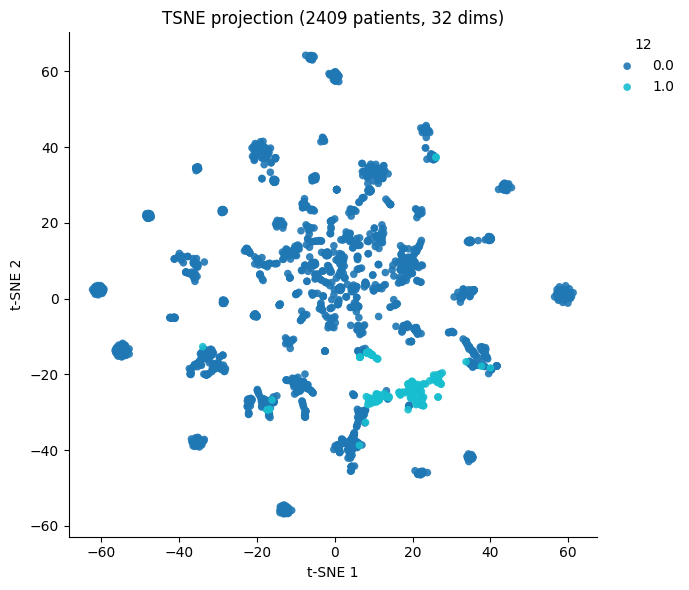

In [25]:
idx = node_order['KG'].values
_ = plot_patient_embeddings(pd.DataFrame(emb.numpy(),index=idx) , node_labels(g_kg).loc[idx][12] , method='TSNE')

In [19]:
import torch
from torch_geometric.utils import from_networkx
import networkx as nx

emb, model = node2vec_gpu_embedding(
    edge_index=edge_index['PSN'],
    num_nodes=edge_index['PSN'].max().numpy()+1,
    embedding_dim=32,
    epochs=500,
    device="cuda",   # will fall back to CPU if not available
    batch_size=512,
)

print(emb.shape)  # torch.Size([34, 64])

Epoch 001/500 | loss=2.7883
Epoch 010/500 | loss=1.5580
Epoch 020/500 | loss=1.0547
Epoch 030/500 | loss=0.8800
Epoch 040/500 | loss=0.8140
Epoch 050/500 | loss=0.7833
Epoch 060/500 | loss=0.7669
Epoch 070/500 | loss=0.7569
Epoch 080/500 | loss=0.7503
Epoch 090/500 | loss=0.7460
Epoch 100/500 | loss=0.7425
Epoch 110/500 | loss=0.7401
Epoch 120/500 | loss=0.7381
Epoch 130/500 | loss=0.7364
Epoch 140/500 | loss=0.7355
Epoch 150/500 | loss=0.7345
Epoch 160/500 | loss=0.7337
Epoch 170/500 | loss=0.7333
Epoch 180/500 | loss=0.7326
Epoch 190/500 | loss=0.7323
Epoch 200/500 | loss=0.7322
Epoch 210/500 | loss=0.7317
Epoch 220/500 | loss=0.7314
Epoch 230/500 | loss=0.7314
Epoch 240/500 | loss=0.7314
Epoch 250/500 | loss=0.7311
Epoch 260/500 | loss=0.7312
Epoch 270/500 | loss=0.7309
Epoch 280/500 | loss=0.7305
Epoch 290/500 | loss=0.7300
Epoch 300/500 | loss=0.7304
Epoch 310/500 | loss=0.7303
Epoch 320/500 | loss=0.7304
Epoch 330/500 | loss=0.7304
Epoch 340/500 | loss=0.7303
Epoch 350/500 | loss

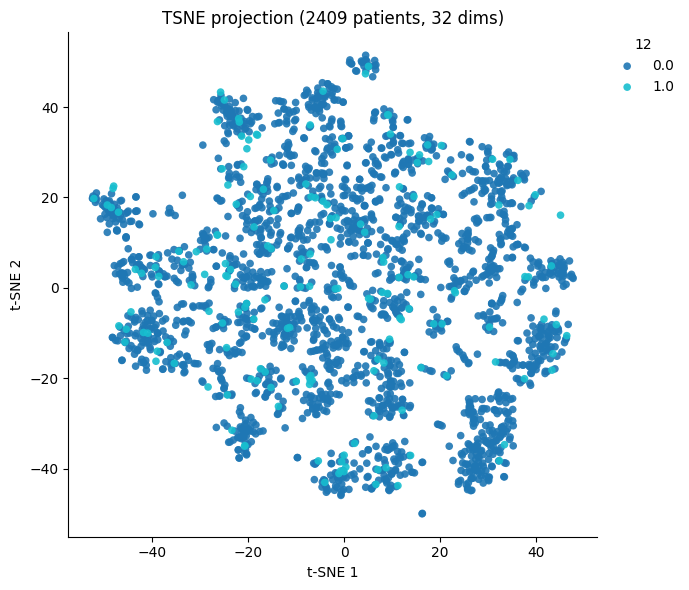

In [23]:
idx = node_order['PSN'].values
_ = plot_patient_embeddings(pd.DataFrame(emb.numpy(),index=idx) , node_labels(g_psn).loc[idx][12] , method='TSNE')